<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
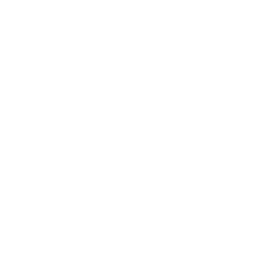
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Retail Packaging and Shelf Position Sales Test</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Retail / Consumer Packaged Goods Marketing &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A retail merchandising team tested four package designs (CLASSIC_BOX, MODERN_POUCH, ECO_WRAP, PREMIUM_TIN) across three shelf positions (eye level, waist level, bottom) in a controlled store experiment, measuring weekly unit sales. A two-way PROC ANOVA on 5,000 store-weeks quantifies how much of the variation in sales each factor explains and whether the two factors interact.

Both main effects are overwhelmingly significant: shelf position is the dominant driver (F = 2430.12, p < 0.0001), and package design also matters (F = 737.98, p < 0.0001). The design x position interaction is significant as well (F = 48.95, p < 0.0001), so the best package depends on where it sits. The model explains 60% of the variance in weekly units (R-Square = 0.5963). Eye-level placement averages 51.6 units per week versus 29.4 at the bottom shelf - a 76% lift that frames the value of premium slotting. These results point the merchandising team toward eye-level facings for the strongest design-position combinations.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.SHELF_TEST | Weekly unit sales by store, package design, and shelf position | 5,000 |

The DATA step below synthesizes the store-week panel with a known mean structure (4 designs x 3 positions) plus store-traffic and normal noise, so the ANOVA recovers effects we can check against the design. The panel spans 100 stores observed over 50 weeks each, giving 5,000 store-week records that the two-way ANOVA analyzes.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic shelf test sales data
   4 package designs x 3 shelf positions across 100 stores
   -------------------------------------------------------- */
data work.shelf_test;
    call streaminit(42);
    length package_design $14 shelf_position $10 store_id $8
           region $12 store_format $10;
    array pkg_labels[4] $14 _temporary_ ('CLASSIC_BOX' 'MODERN_POUCH' 'ECO_WRAP' 'PREMIUM_TIN');
    array shelf_labels[3] $10 _temporary_ ('EYE_LEVEL' 'WAIST_LEVEL' 'BOTTOM');
    array region_labels[4] $12 _temporary_ ('NORTHEAST' 'SOUTHEAST' 'MIDWEST' 'WEST');
    array format_labels[3] $10 _temporary_ ('SUPERSTORE' 'STANDARD' 'EXPRESS');
    /* sales means: rows=package, cols=shelf_position */
    array sales_mean[4, 3] _temporary_ (
        48  42  28
        55  51  35
        41  38  25
        62  53  31
    );
    obs = 0;
    do store_num = 1 to 100;
        store_id = cat('STR-', put(store_num, z4.));
        region_idx = int(rand('uniform') * 4) + 1;
        region = region_labels[region_idx];
        fmt_idx = int(rand('uniform') * 3) + 1;
        store_format = format_labels[fmt_idx];
        store_traffic = round(rand('normal', 5000, 1200), 1);
        if store_traffic < 1000 then store_traffic = 1000;
        do week = 1 to round(50 / (100 / 100));
            pkg_idx = int(rand('uniform') * 4) + 1;
            shelf_idx = int(rand('uniform') * 3) + 1;
            package_design = pkg_labels[pkg_idx];
            shelf_position = shelf_labels[shelf_idx];
            /* weekly units sold with store and random variation */
            weekly_units = round(
                rand('normal',
                    sales_mean[pkg_idx, shelf_idx]
                    + (store_traffic - 5000) * 0.003,
                    8.5),
                1);
            if weekly_units < 0 then weekly_units = 0;
            weekly_revenue = round(weekly_units * rand('normal', 4.29, 0.35), 0.01);
            if weekly_revenue < 0 then weekly_revenue = 0;
            obs + 1;
            output;
        end;
    end;
    drop store_num region_idx fmt_idx pkg_idx shelf_idx obs;
run;

NOTE: DATA work.shelf_test


NOTE: Wrote work.shelf_test (5000 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.91 seconds
  cpu   0.91 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline sales by package design and shelf position
   -------------------------------------------------------- */
proc means data=work.shelf_test n mean std;
    class package_design shelf_position;
    var weekly_units weekly_revenue store_traffic;
run;

                                                  The MEANS Procedure

                                            Analysis Variable : weekly_units

        package_design  shelf_position          N Obs           Mean        Std Dev
        ---------------------------------------------------------------------------
        CLASSIC_BOX     BOTTOM                    413     27.4406780      9.2468568
        CLASSIC_BOX     EYE_LEVEL                 415     47.6240964      9.4415772
        CLASSIC_BOX     WAIST_LEVEL               427     41.3114754      9.1497164
        ECO_WRAP        BOTTOM                    469     24.8742004      9.6725864
        ECO_WRAP        EYE_LEVEL                 361     40.8005540      8.9370701
        ECO_WRAP        WAIST_LEVEL               419     37.0525060      9.3781336
        MODERN_POUCH    BOTTOM                    406     34.9802956      9.1675545
        MODERN_POUCH    EYE_LEVEL                 405     54.6000000      9.3227604
        MOD

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.shelf_test

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


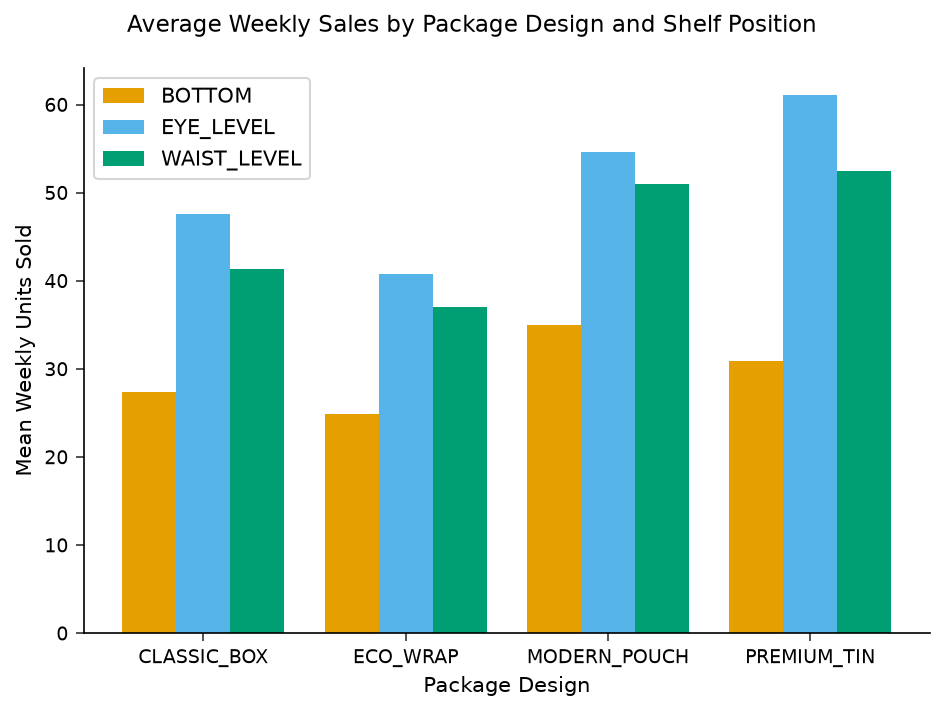

In [3]:
/* --------------------------------------------------------
   Clustered bar chart of mean weekly units
   -------------------------------------------------------- */
proc sgplot data=work.shelf_test;
    vbar package_design / response=weekly_units stat=mean
        group=shelf_position groupdisplay=cluster;
    xaxis label='Package Design';
    yaxis label='Mean Weekly Units Sold';
    title 'Average Weekly Sales by Package Design and Shelf Position';
run;

---

In [4]:
/* --------------------------------------------------------
   Two-way ANOVA: package_design x shelf_position
   on weekly unit sales with interaction.
   Scheffe multiple comparisons on each main effect; the
   interaction cell means are reported by PROC MEANS below.
   -------------------------------------------------------- */
proc anova data=work.shelf_test;
    class package_design shelf_position;
    model weekly_units = package_design shelf_position
                         package_design*shelf_position;
    means package_design shelf_position / scheffe;
    title 'Two-Way ANOVA: Package Design x Shelf Position on Sales';
run;


Dependent Variable: weekly_units

Source                  DF  Sum of Squares     Mean Square    F Value     Pr > F
--------------------------------------------------------------------------------
package_design           3     188169.5305      62723.1768     737.98     0.0000
shelf_position           2     413086.9801     206543.4900    2430.12     0.0000
package_design*shelf     6      24962.0376       4160.3396      48.95     0.0000
Error                 4988     423946.3636         84.9933          .          .
Corrected Total       4999    1050164.9118                          .          .

R-Square: 0.5963  Root MSE: 9.2192  Mean: 42.0042


Scheffe's Test for weekly_units

Alpha                            0.05
Error Degrees of Freedom         4988
Error Mean Square                84.993257

Level of          -----------package_design----------
package_design        N         Mean      Std Dev

CLASSIC_BOX        1255      38.8343      12.5050
ECO_WRAP           1249      33.5629 

NOTE: PROC ANOVA data=work.shelf_test

NOTE: PROC ANOVA: using Python wrapper for advanced features
NOTE: ODS plot written: anova_boxplot.spec.json
NOTE: ODS plot written: anova_diagnostics.spec.json
NOTE: PROC ANOVA: 5000 observations, 3 effects analyzed
NOTE: PROC MEANS
NOTE: Output dataset work.planogram_means has 20 observations and 9 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.planogram_means

NOTE: PROC PRINT completed: 12 observations printed, 9 variables


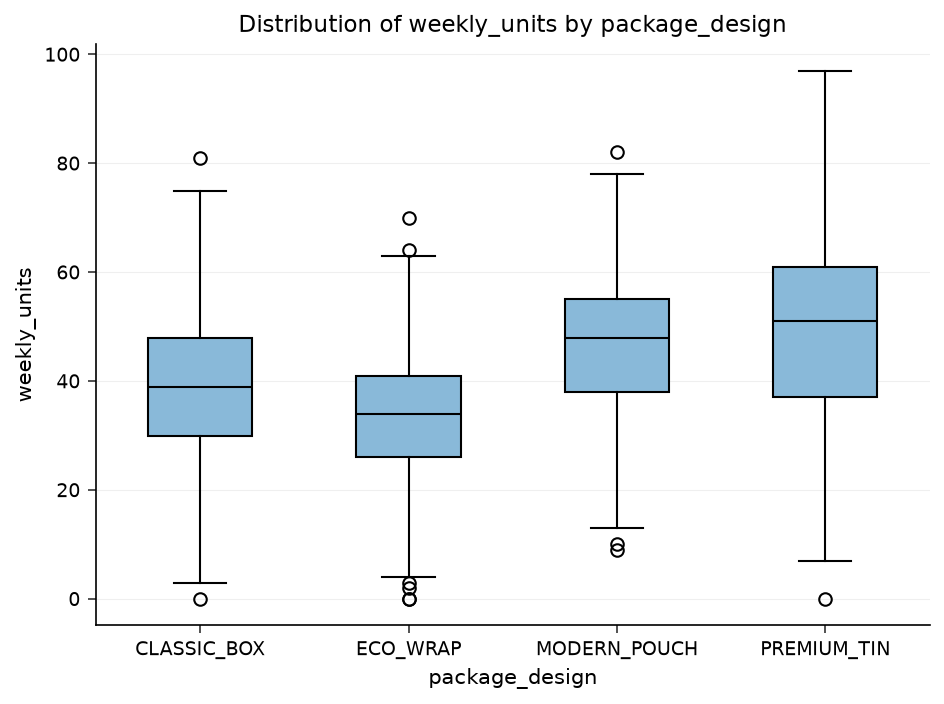

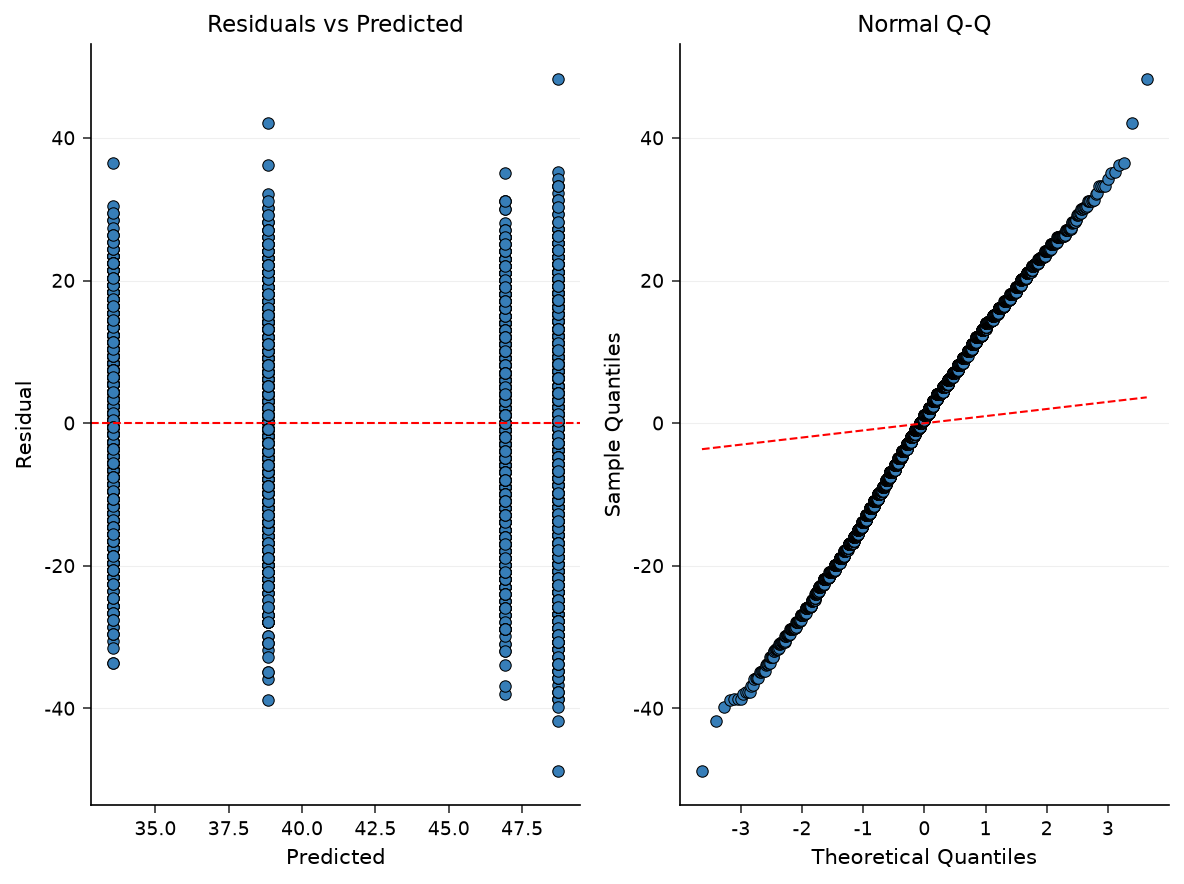

In [5]:
/* --------------------------------------------------------
   Cell means for planogram optimization report
   -------------------------------------------------------- */
proc means data=work.shelf_test n mean std;
    class package_design shelf_position;
    var weekly_units weekly_revenue;
    output out=work.planogram_means
        mean=mean_units mean_revenue
        std=std_units std_revenue
        n=n_weeks;
run;

proc print data=work.planogram_means;
    where _type_ = 3;
    title 'Cell Means: Weekly Sales by Package x Shelf Position';
run;

---

### Interpretation

The two-way ANOVA confirms two significant main effects and a significant interaction on weekly unit sales (5,000 store-weeks, R-Square = 0.5963, Root MSE = 9.22). With the full panel the F statistics are very large and every effect clears p < 0.0001, so the patterns below are estimated precisely rather than being borderline. *(Because of a current Jenner kernel quirk, the PROC ANOVA table, the Scheffe comparisons, and the two diagnostic plots render in the output of the following cell rather than directly beneath the ANOVA code; the numbers quoted here are taken from that output.)*

**Shelf position is the strongest lever.** It contributes the largest sum of squares (413,086.98, F = 2430.12, p < 0.0001). Marginal means are 51.6 units at eye level, 45.4 at waist level, and 29.4 at the bottom shelf. Scheffe's test separates all three positions at the 0.05 level (eye vs bottom difference 22.2, waist vs bottom 16.0, eye vs waist 6.2 - all flagged). The roughly 22-unit gap between eye level and the bottom shelf is the headline result that justifies premium slotting fees for eye-level real estate.

**Package design matters too.** Its main effect is significant (F = 737.98, p < 0.0001) with marginal means of 48.7 (PREMIUM_TIN), 46.9 (MODERN_POUCH), 38.8 (CLASSIC_BOX), and 33.6 (ECO_WRAP). At this sample size Scheffe's test flags every one of the six design pairs as significant at the 0.05 level, including the closest pairing, PREMIUM_TIN vs MODERN_POUCH (difference 1.8 units). PREMIUM_TIN and MODERN_POUCH lead the field, CLASSIC_BOX sits in the middle, and ECO_WRAP trails - ECO_WRAP is 15.2 units behind PREMIUM_TIN and 13.3 behind MODERN_POUCH on average.

**The interaction is real (F = 48.95, p < 0.0001),** so the best design depends on shelf height. The cell-means table makes this concrete: PREMIUM_TIN is the single best cell at eye level (61.1 units) yet drops to 30.9 at the bottom - a swing of about 30 units. MODERN_POUCH is far steadier, holding 54.6 at eye level, 51.0 at waist, and 35.0 at the bottom, the highest bottom-shelf cell of any design. ECO_WRAP is the weakest design at every position (40.8 eye, 37.1 waist, 24.9 bottom).

**Merchandising implications.** Reserve eye-level facings for PREMIUM_TIN where you can guarantee that placement, since its advantage shrinks lower down. Use MODERN_POUCH where shelf position is variable or cannot be controlled, because it loses the least when pushed off eye level. Re-evaluate ECO_WRAP, which underperforms across all positions, unless its margin structure compensates for the lower velocity. (The diagnostic plots - residuals versus predicted and a normal Q-Q plot - show no gross departures from the ANOVA assumptions: the residual spread is even across the fitted cells and the Q-Q points track the reference line closely.)

---

In [6]:
/* --------------------------------------------------------
   Export planogram optimization data
   -------------------------------------------------------- */
proc export data=work.planogram_means
    outfile='packaging_shelf_test_results.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.planogram_means outfile=packaging_shelf_test_results.csv

NOTE: Exported 20 rows to packaging_shelf_test_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>